# Task 4: Literature Database and Bibliometrics

**Master's Thesis:** Heterogeneous Graph Neural Networks for User Journey Modeling

**Author:** Dmitrijs Giždevans

**Data source:** Zotero library export (299 papers)

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import requests
import time
from collections import Counter

## 1. Data Loading and Preprocessing

In [ ]:
# Upload file first, then load
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('my_lib_structured.csv', encoding='utf-8-sig')
print(f"Total papers: {len(df)}")

Saving my_lib_structured.csv to my_lib_structured.csv
Total papers: 299


## 2. Tag Parsing

Extract decision, method, and gap categories from Zotero manual tags.

In [ ]:
# Parse Manual Tags into separate columns
def parse_tags(tags_str):
    if pd.isna(tags_str):
        return {}
    result = {}
    for tag in str(tags_str).split(';'):
        tag = tag.strip()
        if ':' in tag:
            key, val = tag.split(':', 1)
            result[key.strip()] = val.strip()
        elif tag in ['include', 'exclude', 'maybe']:
            result['decision'] = tag
    return result

tags_parsed = df['Manual Tags'].apply(parse_tags)
df['decision'] = tags_parsed.apply(lambda x: x.get('decision', 'unknown'))
df['method'] = tags_parsed.apply(lambda x: x.get('method', 'Unknown'))
df['gap'] = tags_parsed.apply(lambda x: x.get('gap', 'unknown'))

print(df['decision'].value_counts())

decision
include    140
exclude    112
maybe       47
Name: count, dtype: int64


## 3. Publication Trends

### 3.1 Publications by Year

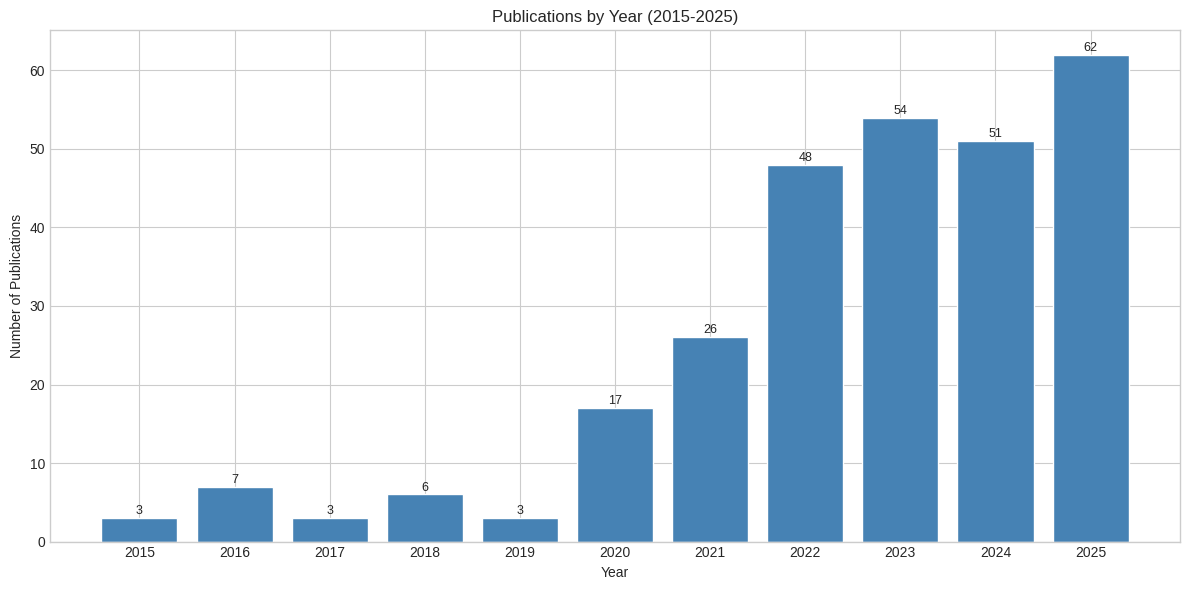

In [ ]:
# Publications by year (2015-2025)
plt.style.use('seaborn-v0_8-whitegrid')

year_counts = df['Publication Year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2015]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(year_counts.index.astype(int), year_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Publications')
ax.set_title('Publications by Year (2015-2025)')
ax.set_xticks(year_counts.index.astype(int))
for bar, val in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_publications_by_year.png', dpi=300)
plt.show()

### 3.2 Distribution by Method Category

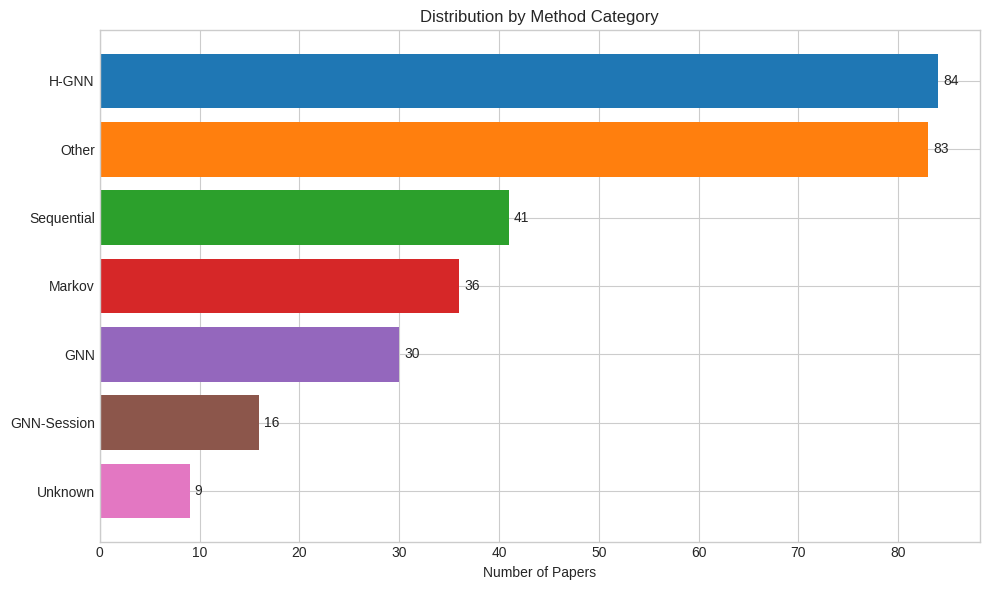

In [ ]:
# Distribution by method category
method_counts = df['method'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax.barh(method_counts.index, method_counts.values, color=colors[:len(method_counts)])
ax.set_xlabel('Number of Papers')
ax.set_title('Distribution by Method Category')
ax.invert_yaxis()
for bar, val in zip(bars, method_counts.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center')
plt.tight_layout()
plt.savefig('fig_distribution_by_method.png', dpi=300)
plt.show()

### 3.3 Screening Decisions

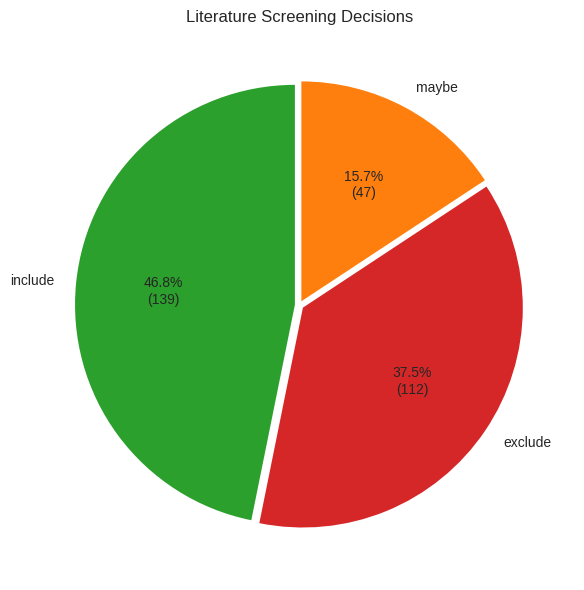

In [ ]:
# Screening decisions pie chart
decision_counts = df['decision'].value_counts()
colors_decision = {'include': '#2ca02c', 'maybe': '#ff7f0e', 'exclude': '#d62728'}

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    decision_counts.values,
    labels=decision_counts.index,
    colors=[colors_decision.get(d, '#7f7f7f') for d in decision_counts.index],
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(decision_counts.values)/100)})',
    startangle=90,
    explode=[0.02]*len(decision_counts)
)
ax.set_title('Literature Screening Decisions')
plt.tight_layout()
plt.savefig('fig_decision_distribution.png', dpi=300)
plt.show()

## 4. Venue and Author Analysis

### 4.1 Top Publication Venues

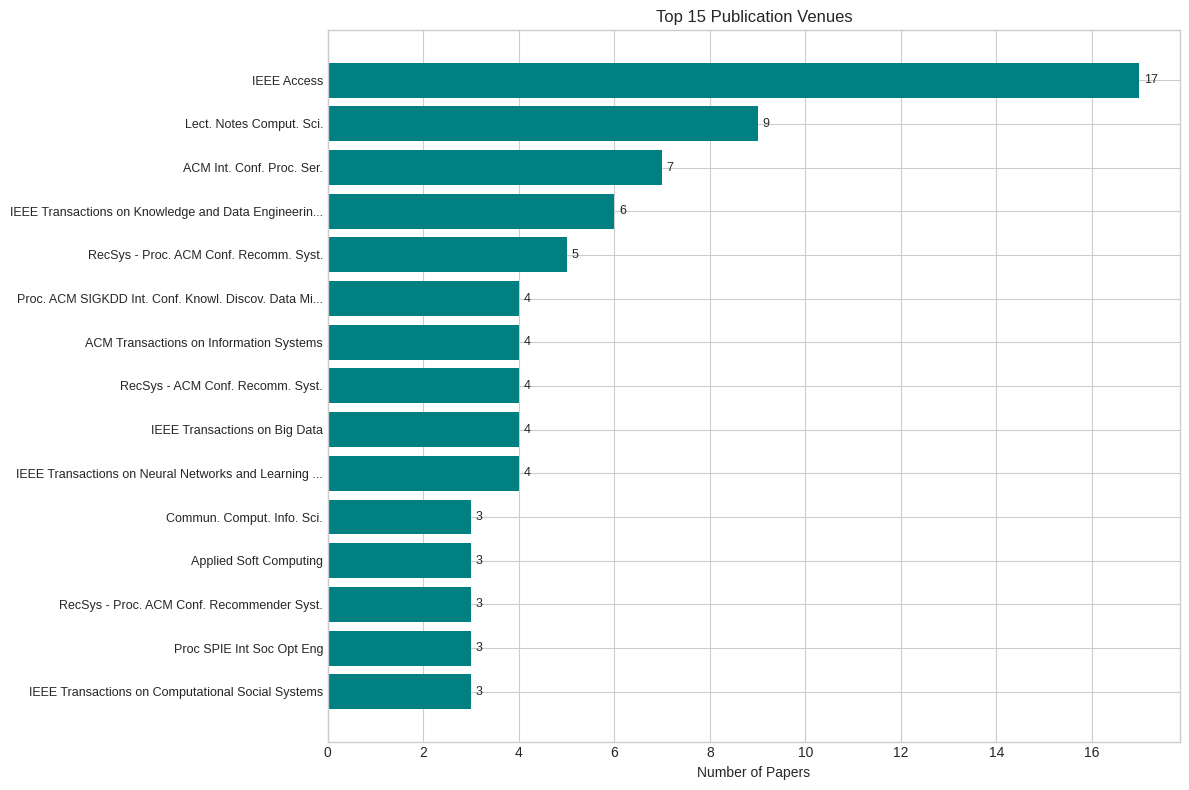

In [ ]:
# Top 15 publication venues
venues = df['Publication Title'].dropna()
venue_counts = venues.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(venue_counts)), venue_counts.values, color='teal')
ax.set_yticks(range(len(venue_counts)))
ax.set_yticklabels([v[:50] + '...' if len(v) > 50 else v for v in venue_counts.index], fontsize=9)
ax.set_xlabel('Number of Papers')
ax.set_title('Top 15 Publication Venues')
ax.invert_yaxis()
for bar, val in zip(bars, venue_counts.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_top_venues.png', dpi=300)
plt.show()

### 4.2 Top Authors

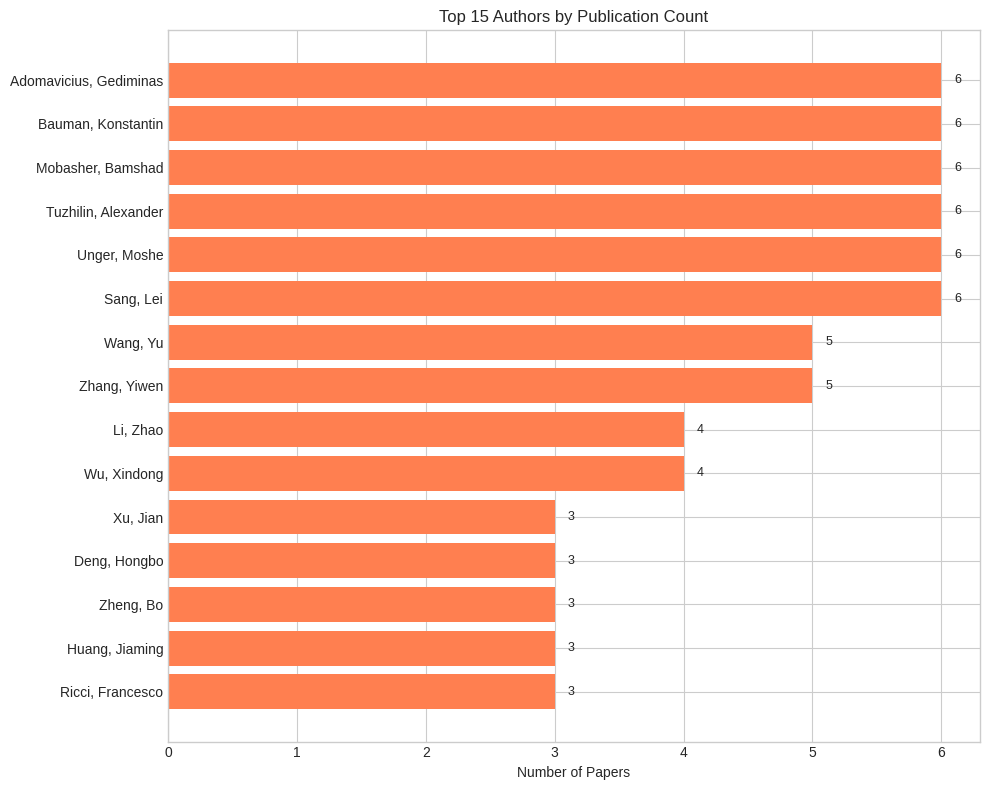

In [ ]:
# Top 15 authors by publication count
all_authors = []
for authors_str in df['Author'].dropna():
    authors = [a.strip() for a in str(authors_str).split(';')]
    all_authors.extend(authors)

author_counts = Counter(all_authors)
top_15 = dict(author_counts.most_common(15))

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(list(top_15.keys()), list(top_15.values()), color='coral')
ax.set_xlabel('Number of Papers')
ax.set_title('Top 15 Authors by Publication Count')
ax.invert_yaxis()
for bar, val in zip(bars, top_15.values()):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_top_authors.png', dpi=300)
plt.show()

## 5. Included Papers Analysis

### 5.1 Method Distribution by Year

Included papers: 140


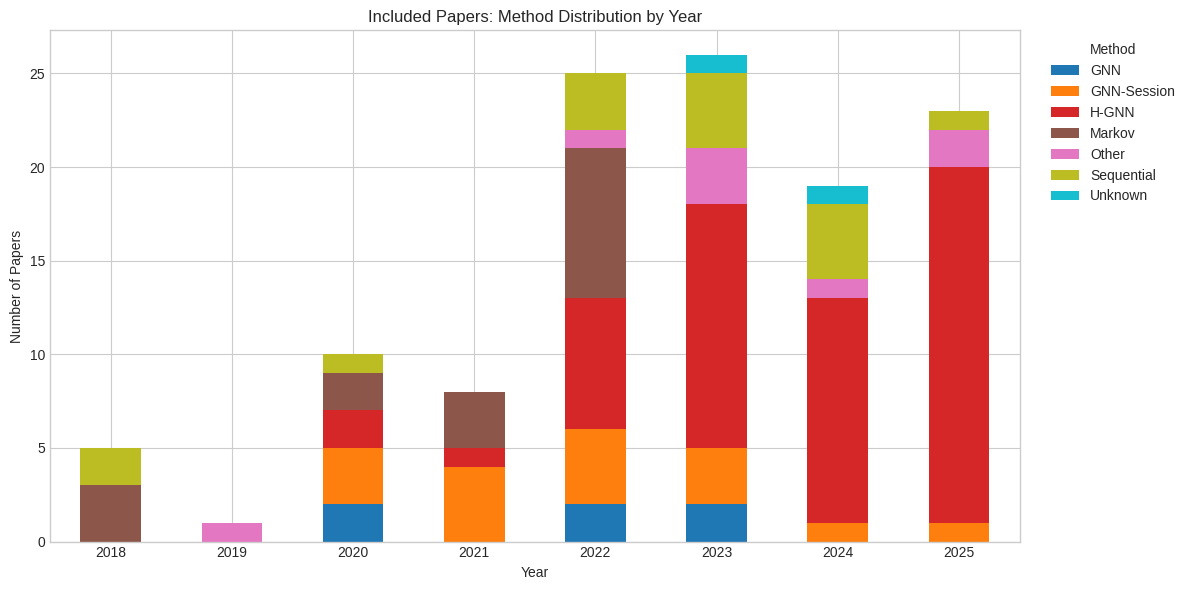

In [ ]:
# Method distribution by year (included papers only)
df_included = df[df['decision'] == 'include'].copy()
print(f"Included papers: {len(df_included)}")

method_year = df_included.groupby(['Publication Year', 'method']).size().unstack(fill_value=0)
method_year = method_year[method_year.index >= 2018]

fig, ax = plt.subplots(figsize=(12, 6))
method_year.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Papers')
ax.set_title('Included Papers: Method Distribution by Year')
ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_method_by_year.png', dpi=300)
plt.show()

### 5.2 Research Gap Classification

gap
core          98
peripheral    36
unknown        6
Name: count, dtype: int64


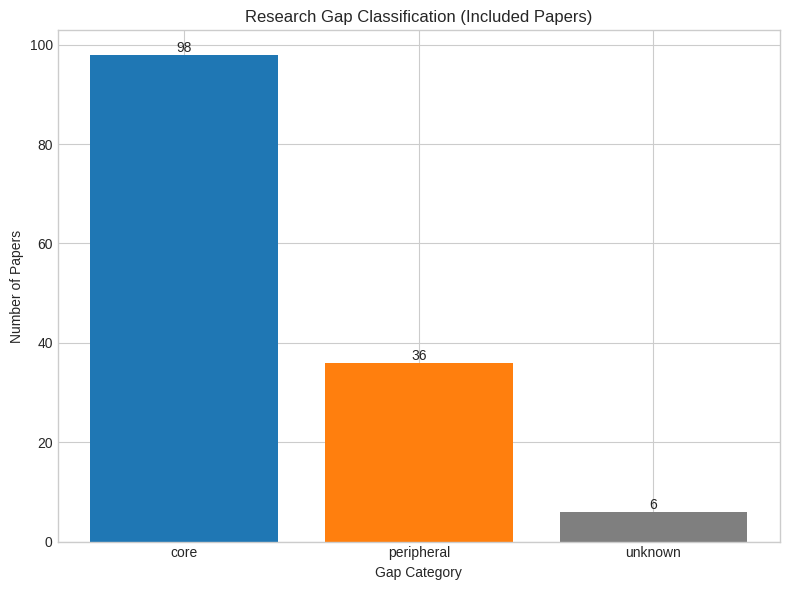

In [ ]:
# Research gap classification (included papers)
gap_counts = df_included['gap'].value_counts()
print(gap_counts)

gap_colors = {'core': '#1f77b4', 'peripheral': '#ff7f0e', 'unknown': '#7f7f7f'}

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(gap_counts.index, gap_counts.values, color=[gap_colors.get(g, '#7f7f7f') for g in gap_counts.index])
ax.set_xlabel('Gap Category')
ax.set_ylabel('Number of Papers')
ax.set_title('Research Gap Classification (Included Papers)')
for bar, val in zip(bars, gap_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center')
plt.tight_layout()
plt.savefig('fig_gap_distribution.png', dpi=300)
plt.show()

## 6. Citation Analysis

Fetching citation counts via Semantic Scholar API.

In [ ]:
# Citation fetch function
def get_citation_count(doi, retries=2):
    if pd.isna(doi) or not doi:
        return None
    for _ in range(retries):
        try:
            url = f"https://api.semanticscholar.org/graph/v1/paper/DOI:{doi}?fields=citationCount"
            resp = requests.get(url, timeout=10)
            if resp.status_code == 200:
                return resp.json().get('citationCount')
            elif resp.status_code == 429:
                time.sleep(5)
            else:
                return None
        except:
            time.sleep(2)
    return None

# Test with one DOI
test_doi = df_included[df_included['DOI'].notna()]['DOI'].iloc[0]
print(f"Testing: {test_doi}")
print(f"Citations: {get_citation_count(test_doi)}")

Testing: 10.1016/j.elerap.2025.101557
Citations: 0


### 6.1 Fetch Citations

In [ ]:
# Fetch citations for all included papers with DOI (~1-2 min)
df_with_doi = df_included[df_included['DOI'].notna()].copy()
print(f"Papers to process: {len(df_with_doi)}")

citations = []
for i, (idx, row) in enumerate(df_with_doi.iterrows()):
    if i % 20 == 0:
        print(f"Processing {i}/{len(df_with_doi)}...")
    citations.append(get_citation_count(row['DOI']))
    time.sleep(0.5)

df_with_doi['citations'] = citations
print(f"\nRetrieved: {df_with_doi['citations'].notna().sum()}/{len(df_with_doi)}")

Papers to process: 138
Processing 0/138...
Processing 20/138...
Processing 40/138...
Processing 60/138...
Processing 80/138...
Processing 100/138...
Processing 120/138...

Retrieved: 133/138


### 6.2 Top Cited Papers

In [ ]:
# Top 15 most cited papers
df_cited = df_with_doi[df_with_doi['citations'].notna()].sort_values('citations', ascending=False)

print("Top 15 Most Cited Papers:")
print("-" * 80)
for i, (_, row) in enumerate(df_cited.head(15).iterrows(), 1):
    title = row['Title'][:55] + '...' if len(str(row['Title'])) > 55 else row['Title']
    print(f"{i:2d}. [{int(row['citations']):4d}] {title} ({int(row['Publication Year'])})")

Top 15 Most Cited Papers:
--------------------------------------------------------------------------------
 1. [3048] Self-Attentive Sequential Recommendation (2018)
 2. [ 308] Evaluation of session-based recommendation algorithms (2018)
 3. [ 204] Deep Learning for Sequential Recommendation (2020)
 4. [  71] A Dual Heterogeneous Graph Attention Network to Improve... (2020)
 5. [  70] Reinforcement Learning on Graphs: A Survey (2023)
 6. [  56] Turning Dross Into Gold Loss: is BERT4Rec really better... (2023)
 7. [  49] Desperately seeking assurances: Segmenting users by the... (2014)
 8. [  47] Graph-Based Embedding Smoothing for Sequential Recommen... (2023)
 9. [  45] Bundle Recommendation and Generation With Graph Neural ... (2023)
10. [  42] Hybrid-Order Gated Graph Neural Network for Session-Bas... (2022)
11. [  40] DGTN: Dual-channel Graph Transition Network for Session... (2020)
12. [  40] Improving Accuracy and Diversity in Matching of Recomme... (2022)
13. [  37] Interactive 

### 6.3 Citation Statistics

In [ ]:
# Citation statistics
print("Citation Statistics:")
print(f"  Papers with data: {len(df_cited)}")
print(f"  Total citations: {int(df_cited['citations'].sum())}")
print(f"  Mean: {df_cited['citations'].mean():.1f}")
print(f"  Median: {df_cited['citations'].median():.0f}")
print(f"  Max: {int(df_cited['citations'].max())}")

Citation Statistics:
  Papers with data: 133
  Total citations: 4730
  Mean: 35.6
  Median: 3
  Max: 3048


### 6.4 Citation Distribution

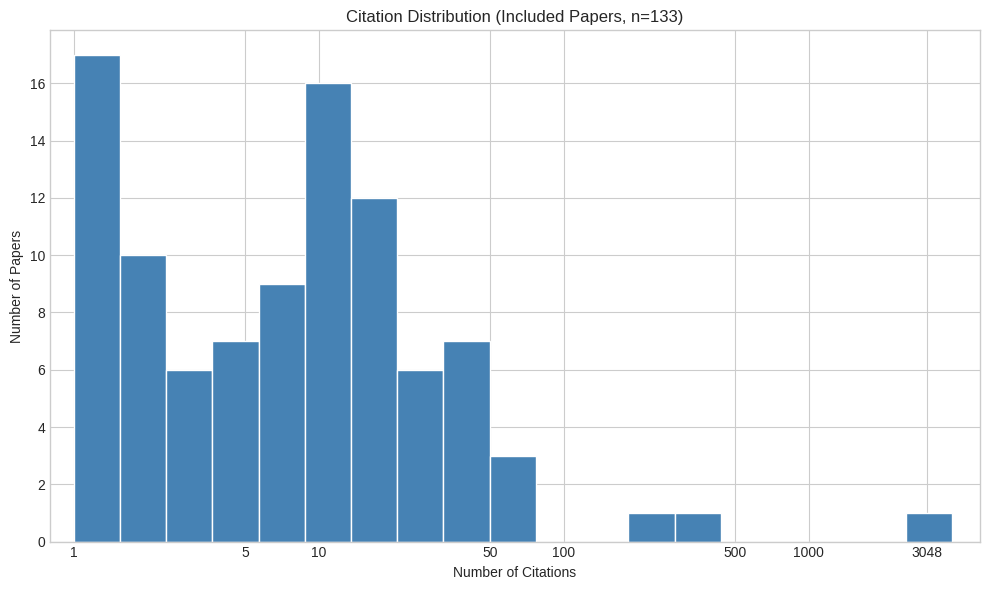

In [ ]:
# Citation distribution with extended x-axis
import numpy as np

df_pos = df_cited[df_cited['citations'] > 0]
bins = np.logspace(0, np.log10(df_pos['citations'].max()) + 0.1, 20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_pos['citations'], bins=bins, color='steelblue', edgecolor='white')
ax.set_xscale('log')
ax.set_xlim(0.8, 5000)
ax.set_xticks([1, 5, 10, 50, 100, 500, 1000, 3048])
ax.set_xticklabels(['1', '5', '10', '50', '100', '500', '1000', '3048'])
ax.set_xlabel('Number of Citations')
ax.set_ylabel('Number of Papers')
ax.set_title('Citation Distribution (Included Papers, n=133)')
plt.tight_layout()
plt.savefig('fig_citation_distribution.png', dpi=300)
plt.show()

## 7. Export and Summary

In [ ]:
# Export results and summary
export_cols = ['Title', 'Author', 'Publication Year', 'Publication Title', 'DOI', 'method', 'gap', 'citations']
df_export = df_with_doi[export_cols].sort_values('citations', ascending=False)
df_export.to_csv('included_papers_bibliometrics.csv', index=False)
print(f"Exported: included_papers_bibliometrics.csv ({len(df_export)} papers)")

print("\n" + "="*60)
print("BIBLIOMETRIC SUMMARY")
print("="*60)
print(f"Total papers: {len(df)}")
print(f"  Include: {len(df[df['decision'] == 'include'])}")
print(f"  Maybe: {len(df[df['decision'] == 'maybe'])}")
print(f"  Exclude: {len(df[df['decision'] == 'exclude'])}")
print(f"Year range: {int(df['Publication Year'].min())}-{int(df['Publication Year'].max())}")
print(f"Citations retrieved: {len(df_cited)}")
print(f"Total citations: {int(df_cited['citations'].sum())}")
print("\nMethod Breakdown (Included):")
print(df_included['method'].value_counts().to_string())

Exported: included_papers_bibliometrics.csv (138 papers)

BIBLIOMETRIC SUMMARY
Total papers: 299
  Include: 140
  Maybe: 47
  Exclude: 112
Year range: 2010-2025
Citations retrieved: 133
Total citations: 4730

Method Breakdown (Included):
method
H-GNN          54
Markov         36
GNN-Session    16
Sequential     15
Other          11
GNN             6
Unknown         2


## 8. Generated Outputs

**Figures:**
- `fig_publications_by_year.png`
- `fig_distribution_by_method.png`
- `fig_decision_distribution.png`
- `fig_top_venues.png`
- `fig_top_authors.png`
- `fig_method_by_year.png`
- `fig_gap_distribution.png`
- `fig_citation_distribution.png`

**Data:**
- `included_papers_bibliometrics.csv` (138 papers with citations)